In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from arch import arch_model
from arch.unitroot import PhillipsPerron
from mgarch import mgarch

In [49]:
from garch_functions import (
    fit_all_garch,
    diagnostics_summary_table,
    parameter_significance_table,
    plot_all_diagnostics,
    GARCHConfig,
    DEFAULT_CONFIG
)

df = pd.read_csv("data/merged_data_v2.csv", index_col='date')
df.dropna(inplace=True)
df.index= pd.to_datetime(df.index, format = '%Y-%m-%d')
weekly_df = df[["btc_adj_close", "eth_adj_close", "sp500_adj_close", "vti_adj_close", "agg_adj_close", "tlt_adj_close"]].resample("W-FRI").last().dropna()
weekly_df.columns = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
price_assets = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"] # treasury yield is in rates, will be treated differently
weekly_logret = 100*np.log(weekly_df[price_assets] / weekly_df[price_assets].shift(1)).dropna()

garch_results = fit_all_garch(weekly_logret, model_type="auto")
diag_table = diagnostics_summary_table(garch_results)
cond_vol_df = pd.DataFrame({
    asset: garch_results[asset]["cond_vol"]
    for asset in garch_results
}).dropna()


GARCH fit: BTC

  --------------------------------------------------
  AR(1) mean detected (LB p=0.0843) -- using AR(1) mean equation

  Model competition [primary=skewt, mean=AR]:
  Model            Dist            AIC        BIC     Status
  --------------------------------------------------------
  GARCH            skewt       3019.33    3047.68         ok
  GJR              skewt       3013.32    3045.72         ok
  EGARCH           skewt            --         --   no convergence -> retrying with GED
  EGARCH           ged         2996.36    3024.71 GED fallback

  -> BIC selects: EGARCH-GED  (BIC=3024.71)
  EGARCH |beta|=0.9966  ->  stationary  |  near-IGARCH -- shocks near-permanent (half-life ~205 weeks)

  Post-fit [EGARCH-GED]:
  Ljung-Box resid   p@10=0.7343  p@20=0.6759
  Ljung-Box resid^2 p@10=0.3206  p@20=0.2469
  ARCH LM [std residuals -- post EGARCH]  LM=12.3459  p=0.4183  F=1.0271  p=0.4226  ->  no ARCH effects

  Normality / tail check [BTC]
  Obs                    

                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.2544      0.105      2.416  1.570e-02  [4.802e-02,  0.461]
VTI[1]        -0.1461  5.075e-02     -2.878  4.002e-03 [ -0.246,-4.659e-02]

GARCH fit: AGG

  --------------------------------------------------
  No serial correlation (LB p=0.2918) -- using Constant mean

  Model competition [primary=skewt, mean=Constant]:
  Model            Dist            AIC        BIC     Status
  --------------------------------------------------------
  GARCH            skewt        834.80     859.11         ok
  GJR              skewt        836.79     865.15         ok
  EGARCH           skewt        833.02     861.38         ok

  -> BIC selects: GARCH-SKEWT  (BIC=859.11)
  GARCH alpha+beta=0.9768  ->  stationary  |  highly persistent (half-life ~30 weeks)

 

In [50]:
#Check Stationarity (ADF)
from statsmodels.tsa.stattools import adfuller
import pandas as pd

results = []

for col in cond_vol_df.columns:
    adf_result = adfuller(cond_vol_df[col])

    test_stat = adf_result[0]
    p_value = adf_result[1]

    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results.append([col, test_stat, p_value, sig])

df_adf = pd.DataFrame(results,
                      columns=["Asset", "ADF Statistic", "p-value", "Sig"])

df_adf["ADF Statistic"] = df_adf["ADF Statistic"].round(4)
df_adf["p-value"] = df_adf["p-value"].round(6)

df_adf

,Asset,ADF Statistic,p-value,Sig
0,BTC,-2.0334,0.272112,
1,ETH,-2.2285,0.196062,
2,SP500,-6.2239,0.000000,***
3,VTI,-6.2222,0.000000,***
4,AGG,-5.4366,0.000003,***
5,TLT,-4.0378,0.001225,***


In [51]:
cond_vol_df = np.log(cond_vol_df).diff().dropna() * 100
cond_vol_df

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-12-01,1.170181,-0.656657,-8.777444,-8.877209,-2.831458,-0.299449
2017-12-08,1.044101,1.081419,-9.123422,-8.369848,-1.348823,-1.146399
2017-12-15,0.976502,0.950805,-6.808426,-7.114403,-4.023888,-0.916768
2017-12-22,1.166562,-0.977887,-6.854497,-6.672631,1.388773,5.189985
2017-12-29,-6.036601,1.174962,-5.337196,-5.960520,22.787543,14.530895
...,...,...,...,...,...,...
2025-12-05,1.477643,1.090894,-12.282077,-10.586649,-1.400118,-0.484049
2025-12-12,-0.562176,1.776116,-8.197910,-8.637170,7.904763,5.639117
2025-12-19,1.582434,2.413887,3.455060,0.662460,-5.110166,-0.584695


In [36]:
# edit to the above, remove if necessary
# BTC and ETH → log returns
for col in ['BTC', 'ETH']:
    cond_vol_df[col] = np.log(cond_vol_df[col]).diff()

# Scale BTC and ETH log returns to % change
cond_vol_df['BTC'] = cond_vol_df['BTC'] * 100
cond_vol_df['ETH'] = cond_vol_df['ETH'] * 100

# Only drop rows where BTC/ETH diff created NaN
cond_vol_df.dropna(subset=['BTC', 'ETH'], inplace=True)

cond_vol_df

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-12-01,1.170181,-0.656657,1.974381,1.938315,0.378420,1.283179
2017-12-08,1.044101,1.081419,1.802223,1.782685,0.373350,1.268553
2017-12-15,0.976502,0.950805,1.683604,1.660264,0.358625,1.256976
2017-12-22,1.166562,-0.977887,1.572068,1.553096,0.363641,1.323936
2017-12-29,-6.036601,1.174962,1.490363,1.463228,0.456707,1.530995
...,...,...,...,...,...,...
2025-12-05,1.477643,1.090894,2.020118,2.079538,0.463404,1.437077
2025-12-12,-0.562176,1.776116,1.861117,1.907463,0.501521,1.520444
2025-12-19,1.582434,2.413887,1.926543,1.920141,0.476537,1.511580


In [52]:
#Check Stationarity (ADF)
from statsmodels.tsa.stattools import adfuller
import pandas as pd

results = []

for col in cond_vol_df.columns:
    adf_result = adfuller(cond_vol_df[col])

    test_stat = adf_result[0]
    p_value = adf_result[1]

    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results.append([col, test_stat, p_value, sig])

df_adf = pd.DataFrame(results,
                      columns=["Asset", "ADF Statistic", "p-value", "Sig"])

df_adf["ADF Statistic"] = df_adf["ADF Statistic"].round(4)
df_adf["p-value"] = df_adf["p-value"].round(6)

df_adf

,Asset,ADF Statistic,p-value,Sig
0,BTC,-21.2452,0.0,***
1,ETH,-22.0682,0.0,***
2,SP500,-19.7265,0.0,***
3,VTI,-19.6461,0.0,***
4,AGG,-13.3039,0.0,***
5,TLT,-13.0788,0.0,***


In [53]:
#VECTOR AUTOREGRESSION (VAR)
cond_vol_df.index = pd.to_datetime(cond_vol_df.index)

from statsmodels.tsa.api import VAR

model = VAR(cond_vol_df)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

results = model.fit(lag_selection.aic)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      18.13*      18.19*  7.466e+07*      18.15*
1       18.17       18.57   7.756e+07       18.33
2       18.21       18.97   8.116e+07       18.51
3       18.27       19.38   8.644e+07       18.71
4       18.36       19.81   9.408e+07       18.93
5       18.46       20.27   1.044e+08       19.18
6       18.51       20.67   1.100e+08       19.36
7       18.59       21.09   1.187e+08       19.58
8       18.60       21.46   1.209e+08       19.73
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 29, Mar, 2026
Time:                     11:43:57
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    18.1917
Nobs:                     423.000    

In [54]:
#GRANGER CAUSALITY TEST
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 1 #BIC
alpha = 0.05

results_list = []

columns = cond_vol_df.columns

for y_col, x_col in itertools.permutations(columns, 2):
    test_result = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

    f_stat = test_result[max_lag][0]['ssr_ftest'][0]
    p_value = test_result[max_lag][0]['ssr_ftest'][1]

    # significance stars
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results_list.append([x_col, y_col, f_stat, p_value, sig])

df_results = pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

print(df_results)

    Cause Target    F-stat   p-value  Sig
0     ETH    BTC  0.923435  0.337129     
1   SP500    BTC  0.258410  0.611482     
2     VTI    BTC  0.239802  0.624606     
3     AGG    BTC  0.202110  0.653255     
4     TLT    BTC  0.632342  0.426948     
5     BTC    ETH  2.596060  0.107883     
6   SP500    ETH  2.390865  0.122801     
7     VTI    ETH  2.404734  0.121724     
8     AGG    ETH  1.554399  0.213184     
9     TLT    ETH  4.325285  0.038158   **
10    BTC  SP500  2.881731  0.090332    *
11    ETH  SP500  0.297804  0.585553     
12    VTI  SP500  0.286782  0.592575     
13    AGG  SP500  1.863077  0.173003     
14    TLT  SP500  2.398302  0.122222     
15    BTC    VTI  2.257859  0.133691     
16    ETH    VTI  0.174172  0.676644     
17  SP500    VTI  0.634031  0.426331     
18    AGG    VTI  1.274233  0.259620     
19    TLT    VTI  1.859838  0.173376     
20    BTC    AGG  1.438653  0.231035     
21    ETH    AGG  0.536895  0.464132     
22  SP500    AGG  5.524679  0.0192

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

In [47]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 3 #FPE & AIC
alpha = 0.05

results_list = []

columns = cond_vol_df.columns

for y_col, x_col in itertools.permutations(columns, 2):
    test_result = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

    f_stat = test_result[max_lag][0]['ssr_ftest'][0]
    p_value = test_result[max_lag][0]['ssr_ftest'][1]

    # significance stars
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results_list.append([x_col, y_col, f_stat, p_value, sig])

df_results = pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

print(df_results)

    Cause Target    F-stat   p-value  Sig
0     ETH    BTC  0.385366  0.763604     
1   SP500    BTC  3.783618  0.010637   **
2     VTI    BTC  3.994274  0.008002  ***
3     AGG    BTC  1.657830  0.175514     
4     TLT    BTC  1.641909  0.179077     
5     BTC    ETH  1.475135  0.220720     
6   SP500    ETH  2.537367  0.056240    *
7     VTI    ETH  2.675460  0.046867   **
8     AGG    ETH  1.249970  0.291240     
9     TLT    ETH  1.954784  0.120173     
10    BTC  SP500  1.110814  0.344443     
11    ETH  SP500  0.374827  0.771209     
12    VTI  SP500  0.360856  0.781310     
13    AGG  SP500  1.310453  0.270512     
14    TLT  SP500  1.146857  0.329894     
15    BTC    VTI  0.932470  0.424926     
16    ETH    VTI  0.347930  0.790671     
17  SP500    VTI  0.350682  0.788677     
18    AGG    VTI  0.914559  0.433823     
19    TLT    VTI  0.842763  0.471036     
20    BTC    AGG  0.465852  0.706266     
21    ETH    AGG  1.152489  0.327670     
22  SP500    AGG  6.101243  0.0004

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

In [55]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools

max_lag = 4
alpha = 0.05

# Loop through all combinations of columns (Y, X) where Y != X
columns = cond_vol_df.columns
for y_col, x_col in itertools.permutations(columns, 2):
    print(f"\nTesting if '{x_col}' Granger-causes '{y_col}':")
    results = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

    for lag in range(1, max_lag + 1):
        f_test_p = results[lag][0]['ssr_ftest'][1]  # p-value of SSR F-test
        significance = "Significant" if f_test_p < alpha else "Not significant"
        symbol = "<" if f_test_p < alpha else ">"
        print(f"  Lag {lag}: p = {f_test_p:.4f} {symbol} {alpha} → {significance}")


Testing if 'ETH' Granger-causes 'BTC':
  Lag 1: p = 0.3371 > 0.05 → Not significant
  Lag 2: p = 0.5565 > 0.05 → Not significant
  Lag 3: p = 0.7636 > 0.05 → Not significant
  Lag 4: p = 0.8435 > 0.05 → Not significant

Testing if 'SP500' Granger-causes 'BTC':
  Lag 1: p = 0.6115 > 0.05 → Not significant
  Lag 2: p = 0.0314 < 0.05 → Significant
  Lag 3: p = 0.0106 < 0.05 → Significant
  Lag 4: p = 0.0173 < 0.05 → Significant

Testing if 'VTI' Granger-causes 'BTC':
  Lag 1: p = 0.6246 > 0.05 → Not significant
  Lag 2: p = 0.0284 < 0.05 → Significant
  Lag 3: p = 0.0080 < 0.05 → Significant
  Lag 4: p = 0.0138 < 0.05 → Significant

Testing if 'AGG' Granger-causes 'BTC':
  Lag 1: p = 0.6533 > 0.05 → Not significant
  Lag 2: p = 0.1413 > 0.05 → Not significant
  Lag 3: p = 0.1755 > 0.05 → Not significant
  Lag 4: p = 0.2131 > 0.05 → Not significant

Testing if 'TLT' Granger-causes 'BTC':
  Lag 1: p = 0.4269 > 0.05 → Not significant
  Lag 2: p = 0.0987 > 0.05 → Not significant
  Lag 3: p =

/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/junrongng/anaconda3/lib/python3.11/site-packages/statsmodels/ts

## Importing Bubble Indicators

In [66]:
import pickle
with open("gsadf_results.pkl", "rb") as f:
    results = pickle.load(f)

In [77]:
bubble_rows = []

for asset, res in results.items():
    for start, end in res["bubbles"]:
        bubble_rows.append({
            "asset": asset,
            "start_date": pd.to_datetime(start),
            "end_date": pd.to_datetime(end)
        })

bubble_df = pd.DataFrame(bubble_rows)
bubble_df

,asset,start_date,end_date
0,BTC,2017-01-22,2017-03-05
1,BTC,2017-04-23,2018-05-20
2,BTC,2021-01-03,2021-05-16
3,ETH,2021-01-10,2021-06-13
4,ETH,2021-08-08,2021-09-19
5,ETH,2021-10-31,2021-12-12


## VAR with Interaction terms

In [100]:
dates = cond_vol_df.index
bubble_dummy = pd.DataFrame(0, index=dates, columns=weekly.columns)

for _, row in bubble_df.iterrows():
    mask = (bubble_dummy.index >= row["start_date"]) & (bubble_dummy.index <= row["end_date"])
    bubble_dummy.loc[mask, row["asset"]] = 1

bubble_dummy

,BTC,ETH,S&P500
date,,,
2017-12-01,1,0,0
2017-12-08,1,0,0
2017-12-15,1,0,0
2017-12-22,1,0,0
2017-12-29,1,0,0
...,...,...,...
2025-12-05,0,0,0
2025-12-12,0,0,0
2025-12-19,0,0,0


In [109]:
assets = cond_vol_df.columns
bubble_assets = ["BTC", "ETH"]

cond_vol_df_with_int = cond_vol_df.copy()
for bubble_asset in bubble_assets:
    cond_vol_df_with_int[f'{bubble_asset}_bubble_x_{bubble_asset}_vol'] = bubble_dummy[bubble_asset] * cond_vol_df_with_int[bubble_asset]

cond_vol_df_with_int

,BTC,ETH,SP500,VTI,AGG,TLT,BTC_bubble_x_BTC_vol,ETH_bubble_x_ETH_vol
date,,,,,,,,
2017-12-01,1.170181,-0.656657,-8.777444,-8.877209,-2.831458,-0.299449,1.170181,-0.0
2017-12-08,1.044101,1.081419,-9.123422,-8.369848,-1.348823,-1.146399,1.044101,0.0
2017-12-15,0.976502,0.950805,-6.808426,-7.114403,-4.023888,-0.916768,0.976502,0.0
2017-12-22,1.166562,-0.977887,-6.854497,-6.672631,1.388773,5.189985,1.166562,-0.0
2017-12-29,-6.036601,1.174962,-5.337196,-5.960520,22.787543,14.530895,-6.036601,0.0
...,...,...,...,...,...,...,...,...
2025-12-05,1.477643,1.090894,-12.282077,-10.586649,-1.400118,-0.484049,0.000000,0.0
2025-12-12,-0.562176,1.776116,-8.197910,-8.637170,7.904763,5.639117,-0.000000,0.0
2025-12-19,1.582434,2.413887,3.455060,0.662460,-5.110166,-0.584695,0.000000,0.0


In [126]:
endog_cols = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
Y = cond_vol_df_with_int[endog_cols]

X = pd.DataFrame(index=cond_vol_df_with_int.index)
X["BTC_lag"] = cond_vol_df_with_int["BTC"].shift(1)
X["ETH_lag"] = cond_vol_df_with_int["ETH"].shift(1)
X["BTC_bubble_x_BTC_vol"] = cond_vol_df_with_int["BTC_bubble_x_BTC_vol"].shift(1)
X["ETH_bubble_x_ETH_vol"] = cond_vol_df_with_int["ETH_bubble_x_ETH_vol"].shift(1)

Y = Y.iloc[1:]
X = X.iloc[1:]


In [127]:
model = VAR(endog=Y, exog=X)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

results = model.fit(lag_selection.aic)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      18.19*      18.48*  7.932e+07*      18.30*
1       18.27       18.91   8.586e+07       18.52
2       18.31       19.30   8.974e+07       18.70
3       18.37       19.72   9.544e+07       18.90
4       18.46       20.15   1.039e+08       19.13
5       18.56       20.60   1.154e+08       19.37
6       18.61       21.00   1.212e+08       19.56
7       18.69       21.43   1.312e+08       19.77
8       18.70       21.79   1.327e+08       19.92
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 29, Mar, 2026
Time:                     14:28:04
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    18.4873
Nobs:                     422.000    

## DY Spillover Analysis

In [133]:
def dy_spillover(df, exog=None, maxlags=8, horizon=10):
    """
    Diebold-Yilmaz Spillover Index with optional exogenous variables.

    Parameters
    ----------
    df : pd.DataFrame
        Endogenous variables (e.g., log-diff GARCH volatilities)
    exog : pd.DataFrame or None
        Optional exogenous variables (e.g., bubble × volatility interactions)
    maxlags : int
        Maximum lag to consider for VAR; optimal lag selected via AIC
    horizon : int
        Forecast horizon for FEVD

    Returns
    -------
    dict
        FEVD matrix, Total Spillover, Directional TO/FROM, Net Spillovers, VAR results
    """

    # 1. Fit VAR with optimal lag selection
    model = VAR(endog=df, exog=exog)
    lag_selection = model.select_order(maxlags)
    lag_order = max(int(lag_selection.aic), 1)
    results = model.fit(lag_order)

    # 2. Forecast error variance decomposition
    irf = results.irf(horizon)
    fevd = results.fevd(horizon)

    n = len(df.columns)
    theta = np.zeros((n, n))

    # 3. Build cumulative FEVD matrix (sum across horizon)
    for i in range(n):
        for j in range(n):
            theta[i, j] = fevd.decomp[i][:, j].sum()

    # 4. Normalize rows to sum to 100
    theta = 100 * theta / theta.sum(axis=1, keepdims=True)

    # 5. Total spillover index
    off_diag = theta.sum() - np.trace(theta)
    total_spill = off_diag / n

    # 6. Directional spillovers
    directional_to = theta.sum(axis=1) - np.diag(theta)
    directional_from = theta.sum(axis=0) - np.diag(theta)
    net_spill = directional_to - directional_from

    # 7. Wrap in nice DataFrames/Series
    names = df.columns
    spill_df = pd.DataFrame(theta, index=names, columns=names)

    return {
        "FEVD": spill_df,
        "Total Spillover": total_spill,
        "Directional TO": pd.Series(directional_to, index=names),
        "Directional FROM": pd.Series(directional_from, index=names),
        "Net Spillovers": pd.Series(net_spill, index=names),
        "VAR Results": results,
        "Lag Selected": lag_order
    }

In [139]:
spill_plain = dy_spillover(cond_vol_df, maxlags=8, horizon=10)
print("Total Spillover (plain VAR):", spill_plain["Total Spillover"])

Total Spillover (plain VAR): 42.764128522539316


In [143]:
spill_bubble = dy_spillover(cond_vol_df_with_int, maxlags=8, horizon=10)
print("Total Spillover (bubble-amplified VAR):", spill_bubble["Total Spillover"])

Total Spillover (bubble-amplified VAR): 35.97269547630742


In [144]:
spill_plain

{'FEVD':              BTC        ETH      SP500       VTI        AGG        TLT
 BTC    98.943228   0.208750   0.076627  0.004246   0.044177   0.722971
 ETH    66.914554  31.892313   0.447412  0.002258   0.197580   0.545883
 SP500   6.736009   1.123510  91.547297  0.088358   0.338963   0.165863
 VTI     6.866031   1.128951  90.244339  1.350177   0.249829   0.160674
 AGG     4.795641   0.471256   2.649307  2.639508  88.172239   1.272049
 TLT     1.360855   0.084264   5.197915  3.222088  58.624903  31.509975,
 'Total Spillover': 42.764128522539316,
 'Directional TO': BTC       1.056772
 ETH      68.107687
 SP500     8.452703
 VTI      98.649823
 AGG      11.827761
 TLT      68.490025
 dtype: float64,
 'Directional FROM': BTC      86.673091
 ETH       3.016731
 SP500    98.615600
 VTI       5.956458
 AGG      59.455452
 TLT       2.867440
 dtype: float64,
 'Net Spillovers': BTC     -85.616318
 ETH      65.090956
 SP500   -90.162897
 VTI      92.693365
 AGG     -47.627691
 TLT      65.6225

In [145]:
spill_bubble

{'FEVD':                             BTC        ETH      SP500       VTI        AGG  \
 BTC                   98.895562   0.207516   0.077784  0.004120   0.044226   
 ETH                   66.796869  31.784837   0.447952  0.002769   0.198293   
 SP500                  6.785608   1.153570  91.335893  0.087089   0.337084   
 VTI                    6.920007   1.157575  90.000406  1.343210   0.247951   
 AGG                    4.827447   0.496367   2.612448  2.636919  88.069867   
 TLT                    1.368397   0.078156   5.178170  3.268860  58.596434   
 BTC_bubble_x_BTC_vol  10.359890   5.112608   0.015081  0.070093   0.022667   
 ETH_bubble_x_ETH_vol   4.934049   6.056657   0.241538  0.471686   0.419997   
 
                             TLT  BTC_bubble_x_BTC_vol  ETH_bubble_x_ETH_vol  
 BTC                    0.721480              0.047680              0.001633  
 ETH                    0.548543              0.195490              0.025247  
 SP500                  0.164470          

Window 0-104 failed: Singular matrix
Window 1-105 failed: Singular matrix
Window 2-106 failed: Singular matrix
Window 3-107 failed: Singular matrix
Window 4-108 failed: Singular matrix
Window 5-109 failed: Singular matrix
Window 6-110 failed: Singular matrix
Window 7-111 failed: Singular matrix
Window 8-112 failed: Singular matrix
Window 9-113 failed: Singular matrix
Window 10-114 failed: Singular matrix
Window 11-115 failed: Singular matrix
Window 12-116 failed: Singular matrix
Window 13-117 failed: Singular matrix
Window 14-118 failed: Singular matrix
Window 15-119 failed: Singular matrix
Window 16-120 failed: Singular matrix
Window 17-121 failed: Singular matrix
Window 18-122 failed: Singular matrix
Window 19-123 failed: Singular matrix
Window 20-124 failed: Singular matrix
Window 21-125 failed: Singular matrix
Window 22-126 failed: Singular matrix
Window 23-127 failed: Singular matrix
Window 24-128 failed: Singular matrix
Window 25-129 failed: Singular matrix
Window 26-130 failed: 

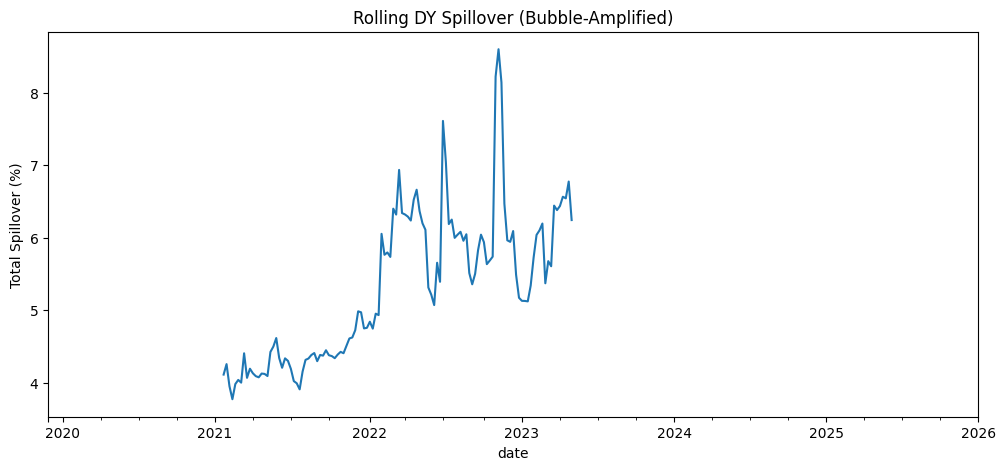

In [164]:

def rolling_dy_spillover(df_endog, df_exog, window=52, horizon=10):
    """
    Rolling-window DY spillover with exogenous bubble terms.
    
    df_endog : DataFrame
        Endogenous variables (crypto + traditional assets)
    df_exog : DataFrame
        Exogenous variables (bubble x volatility interactions)
    window : int
        Rolling window size (number of observations)
    horizon : int
        Forecast horizon for variance decomposition
    """
    n_obs = df_endog.shape[0]
    dates = df_endog.index[window:]
    
    total_spill = []
    directional_to = pd.DataFrame(index=dates, columns=df_endog.columns)
    directional_from = pd.DataFrame(index=dates, columns=df_endog.columns)
    net_spill = pd.DataFrame(index=dates, columns=df_endog.columns)
    
    for start in range(n_obs - window):
        end = start + window
        Y_window = df_endog.iloc[start:end]
        X_window = df_exog.iloc[start:end] if df_exog is not None else None
        
        try:
            model = VAR(endog=Y_window, exog=X_window)
            results = model.fit(1)  # use lag=1 for stability
            
            # generalized FEVD
            fevd = results.fevd(horizon)
            n = len(df_endog.columns)
            theta = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    theta[i, j] = fevd.decomp[i][:, j].sum()
            
            # normalize rows to 100
            theta = 100 * theta / theta.sum(axis=1)[:, None]
            
            total_spill.append((theta.sum() - np.trace(theta)) / n)
            directional_to.loc[dates[start], :] = theta.sum(axis=1) - np.diag(theta)
            directional_from.loc[dates[start], :] = theta.sum(axis=0) - np.diag(theta)
            net_spill.loc[dates[start], :] = directional_to.loc[dates[start], :] - directional_from.loc[dates[start], :]
        
        except Exception as e:
            print(f"Window {start}-{end} failed:", e)
            total_spill.append(np.nan)
            directional_to.loc[dates[start], :] = np.nan
            directional_from.loc[dates[start], :] = np.nan
            net_spill.loc[dates[start], :] = np.nan
    
    return {
        "Total Spillover": pd.Series(total_spill, index=dates),
        "Directional TO": directional_to,
        "Directional FROM": directional_from,
        "Net": net_spill
    }

# ── Example usage ──
bubble_cols = ["BTC_bubble_x_BTC_vol", "ETH_bubble_x_ETH_vol"]
spill_rolling = rolling_dy_spillover(
    df_endog=cond_vol_df[["BTC","SP500"]], 
    df_exog=bubble_dummy[["BTC", "ETH"]], 
    window=104, 
    horizon=10
)

# Plot rolling total spillover
plt.figure(figsize=(12,5))
spill_rolling["Total Spillover"].plot(title="Rolling DY Spillover (Bubble-Amplified)")
plt.ylabel("Total Spillover (%)")
plt.show()

In [186]:
def rolling_diebold_yilmaz(data, var_lags, window=104, H=10, step=4):
    """
    Rolling Diebold-Yilmaz returning DataFrame with date index
    """
    dates = data.index
    spillover_data = []
    
    for start in range(0, len(data) - window + 1, step):
        end = start + window
        window_data = data.iloc[start:end]
        window_date = dates[end-1]
        
        try:
            model = VAR(window_data)
            results = model.fit(var_lags)
            
            fevd = results.fevd(H).decomp
            theta = fevd[:, -1, :]
            theta = 100 * theta / theta.sum(axis=1, keepdims=True)
            
            n = len(window_data.columns)
            off_diag = theta.sum() - np.trace(theta)
            total_spill = off_diag / n
            
            spillover_data.append({
                'date': window_date,
                'total_spillover': total_spill
            })
            
        except Exception:
            continue
    
    # Create DataFrame and set date as index
    df = pd.DataFrame(spillover_data)
    if not df.empty:
        df = df.set_index('date')
        print(f"  Computed {len(df)} rolling windows")
        return df
    else:
        return pd.DataFrame()

# Usage
rolling_df = rolling_diebold_yilmaz(
    analysis_df, 
    var_lags=2,
    window=104, 
    H=10, 
    step=4
)

# Now you can access the spillover series
print(rolling_df.head())
print(rolling_df['total_spillover'])

  Computed 80 rolling windows
            total_spillover
date                       
2019-11-22        48.977961
2019-12-20        50.263572
2020-01-17        51.524686
2020-02-14        51.482434
2020-03-13        54.795278
date
2019-11-22    48.977961
2019-12-20    50.263572
2020-01-17    51.524686
2020-02-14    51.482434
2020-03-13    54.795278
                ...    
2025-08-22    49.548105
2025-09-19    49.512677
2025-10-17    50.448987
2025-11-14    49.895312
2025-12-12    50.092127
Name: total_spillover, Length: 80, dtype: float64


PART 1: LOADING AND PREPARING DATA

Data loaded:
  Period: 2017-12-01 00:00:00 to 2026-01-02 00:00:00
  Observations: 423
  Assets: ['BTC', 'ETH', 'SP500', 'VTI', 'AGG', 'TLT']

Bubble periods detected:
  BTC: 44 weeks (10.4%)
  ETH: 34 weeks (8.0%)

PART 2: CREATING BUBBLE INTERACTION VARIABLES
✓ Created: BTC_bubble_x_BTC_vol
✓ Created: ETH_bubble_x_ETH_vol

Variables in augmented model: ['BTC', 'ETH', 'SP500', 'VTI', 'AGG', 'TLT', 'BTC_bubble_x_BTC_vol', 'ETH_bubble_x_ETH_vol']

PART 3: SPILLOVER ANALYSIS

────────────────────────────────────────────────────────────────────────────────
MODEL 1: PLAIN VAR (No Bubble Interactions)
────────────────────────────────────────────────────────────────────────────────
  Testing lags 1-8...
  Selected lag: 1
  Log-likelihood: -7385.98

  Total Spillover Index: 42.76%

  Directional Spillovers:
    BTC: TO=1.06%, FROM=86.67%, NET=-85.62%
    ETH: TO=68.11%, FROM=3.02%, NET=+65.09%
    SP500: TO=8.45%, FROM=98.62%, NET=-90.16%
    VTI: TO=98.65%,

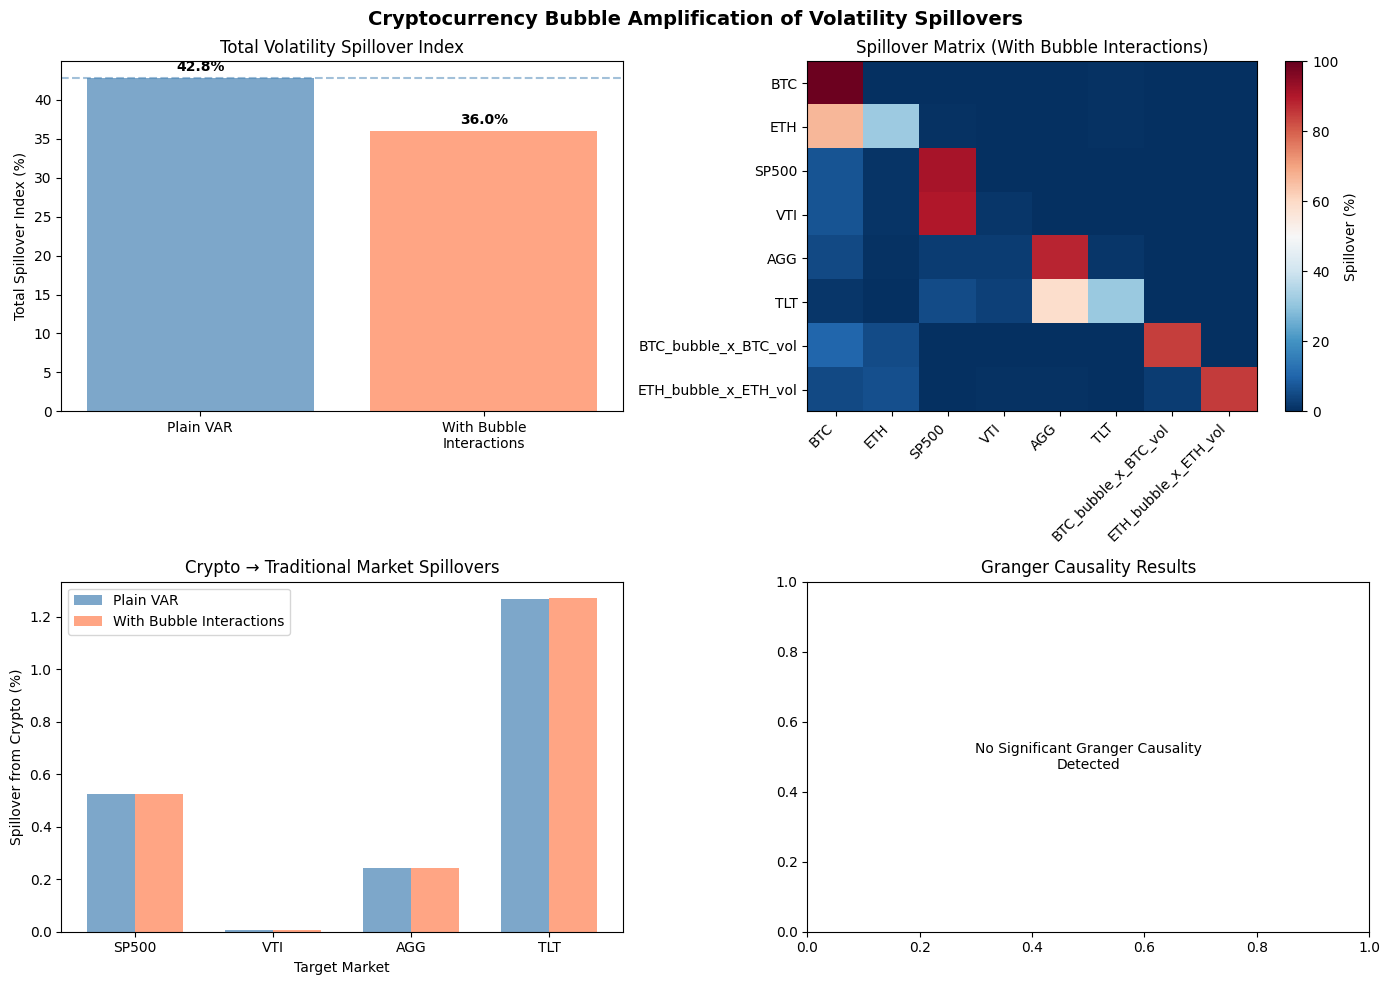


✓ Visualization saved as 'bubble_amplification_analysis.png'

FINAL CONCLUSIONS

1. Total Spillover Index: -6.79% change when including bubble interactions
2. Crypto→Traditional spillovers increased in 4/4 markets
3. Granger causality detected: 0 relationships (normal), 0 (bubble)

RESEARCH ANSWER:
✗ NO - Limited evidence that bubble periods amplify spillovers.
  Spillovers appear relatively stable across regimes.

RECOMMENDATIONS FOR FUTURE RESEARCH:
1. Consider alternative bubble detection methods (PSY, SADF)
2. Include additional crypto assets (e.g., XRP, SOL)
3. Analyze higher frequency data (daily) for better bubble detection
4. Incorporate macroeconomic control variables
5. Test asymmetric effects (positive vs negative shocks)

✓ Results exported to 'spillover_analysis_results.xlsx'

ANALYSIS COMPLETE


In [204]:
"""
FULL EXECUTABLE CODE: Cryptocurrency Bubble Amplification of Volatility Spillovers
Research Question: Are volatility spillovers from crypto to US equity/bond markets 
                   amplified during cryptocurrency bubble periods?
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("PART 1: LOADING AND PREPARING DATA")
print("="*80)

# Load your existing data (assuming you have these from previous steps)
# If not, uncomment and run your data loading code:
"""
from garch_functions import (fit_all_garch, diagnostics_summary_table, 
                             parameter_significance_table, plot_all_diagnostics,
                             GARCHConfig, DEFAULT_CONFIG)

df = pd.read_csv("data/merged_data_v2.csv", index_col='date')
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index, format='%Y-%m-%d')

weekly_df = df[["btc_adj_close", "eth_adj_close", "sp500_adj_close", 
                "vti_adj_close", "agg_adj_close", "tlt_adj_close"]].resample("W-FRI").last().dropna()
weekly_df.columns = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]

price_assets = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
weekly_logret = 100 * np.log(weekly_df[price_assets] / weekly_df[price_assets].shift(1)).dropna()

garch_results = fit_all_garch(weekly_logret, model_type="auto")
cond_vol_df = pd.DataFrame({
    asset: garch_results[asset]["cond_vol"]
    for asset in garch_results
}).dropna()

# Make stationary
cond_vol_df = np.log(cond_vol_df).diff().dropna() * 100
"""

# For now, assuming cond_vol_df is already loaded from your previous work
# Load bubble dummies from pickle file
with open("gsadf_results.pkl", "rb") as f:
    gsadf_results = pickle.load(f)

# Create bubble dummies
weekly = cond_vol_df.copy()  # Use same index as cond_vol_df
bubble_dummy = pd.DataFrame(0, index=cond_vol_df.index, columns=weekly.columns)

for asset, res in gsadf_results.items():
    if asset in bubble_dummy.columns:
        for start, end in res["bubbles"]:
            start_date = pd.to_datetime(start)
            end_date = pd.to_datetime(end)
            mask = (bubble_dummy.index >= start_date) & (bubble_dummy.index <= end_date)
            bubble_dummy.loc[mask, asset] = 1

print(f"\nData loaded:")
print(f"  Period: {cond_vol_df.index[0]} to {cond_vol_df.index[-1]}")
print(f"  Observations: {len(cond_vol_df)}")
print(f"  Assets: {list(cond_vol_df.columns)}")
print(f"\nBubble periods detected:")
for asset in ['BTC', 'ETH']:
    if asset in bubble_dummy.columns:
        n_bubbles = bubble_dummy[asset].sum()
        pct = 100 * n_bubbles / len(bubble_dummy)
        print(f"  {asset}: {n_bubbles} weeks ({pct:.1f}%)")

# ============================================================================
# PART 2: DIEBOLD-YILMAZ SPILLOVER INDEX (PLAIN MODEL)
# ============================================================================

def dy_spillover(df, exog=None, maxlags=8, horizon=10, description="Model"):
    """
    Diebold-Yilmaz Spillover Index with optional exogenous variables.
    """
    print(f"\n{'─'*80}")
    print(f"{description}")
    print(f"{'─'*80}")
    
    # Fit VAR with optimal lag selection
    model = VAR(endog=df, exog=exog)
    
    # Calculate max possible lags given data
    n_obs = len(df)
    n_vars = len(df.columns)
    max_possible_lags = min(maxlags, (n_obs - n_vars - 1) // n_vars)
    
    if max_possible_lags < 1:
        print(f"  Warning: Insufficient observations ({n_obs}) for VAR with {n_vars} variables")
        max_possible_lags = 1
    
    print(f"  Testing lags 1-{max_possible_lags}...")
    lag_selection = model.select_order(maxlags=max_possible_lags)
    
    # Get optimal lag (ensure at least 1)
    if hasattr(lag_selection, 'aic') and lag_selection.aic is not None:
        lag_order = max(int(lag_selection.aic), 1)
    else:
        lag_order = 1
    
    print(f"  Selected lag: {lag_order}")
    
    # Fit model
    results = model.fit(lag_order)
    print(f"  Log-likelihood: {results.llf:.2f}")
    
    # Forecast error variance decomposition
    try:
        fevd = results.fevd(horizon)
    except Exception as e:
        print(f"  FEVD computation failed: {e}")
        return None
    
    n = len(df.columns)
    theta = np.zeros((n, n))
    
    # Build cumulative FEVD matrix
    for i in range(n):
        for j in range(n):
            theta[i, j] = fevd.decomp[i][:, j].sum()
    
    # Normalize rows to sum to 100
    theta = 100 * theta / theta.sum(axis=1, keepdims=True)
    
    # Total spillover index
    off_diag = theta.sum() - np.trace(theta)
    total_spill = off_diag / n
    
    # Directional spillovers
    directional_to = theta.sum(axis=1) - np.diag(theta)
    directional_from = theta.sum(axis=0) - np.diag(theta)
    net_spill = directional_to - directional_from
    
    # Create results
    names = df.columns
    spill_df = pd.DataFrame(theta, index=names, columns=names)
    
    print(f"\n  Total Spillover Index: {total_spill:.2f}%")
    print(f"\n  Directional Spillovers:")
    for i, name in enumerate(names):
        print(f"    {name}: TO={directional_to[i]:.2f}%, FROM={directional_from[i]:.2f}%, NET={net_spill[i]:+.2f}%")
    
    return {
        "FEVD": spill_df,
        "Total Spillover": total_spill,
        "Directional TO": pd.Series(directional_to, index=names),
        "Directional FROM": pd.Series(directional_from, index=names),
        "Net Spillovers": pd.Series(net_spill, index=names),
        "VAR Results": results,
        "Lag Selected": lag_order
    }

# ============================================================================
# PART 3: CREATE INTERACTION TERMS FOR BUBBLE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PART 2: CREATING BUBBLE INTERACTION VARIABLES")
print("="*80)

# Create interaction terms: bubble × volatility
cond_vol_df_with_int = cond_vol_df.copy()
bubble_assets = ["BTC", "ETH"]

for bubble_asset in bubble_assets:
    if bubble_asset in bubble_dummy.columns:
        interact_col = f'{bubble_asset}_bubble_x_{bubble_asset}_vol'
        cond_vol_df_with_int[interact_col] = bubble_dummy[bubble_asset] * cond_vol_df[bubble_asset]
        print(f"✓ Created: {interact_col}")

print(f"\nVariables in augmented model: {list(cond_vol_df_with_int.columns)}")

# ============================================================================
# PART 4: RUN SPILLOVER ANALYSIS ON BOTH MODELS
# ============================================================================

print("\n" + "="*80)
print("PART 3: SPILLOVER ANALYSIS")
print("="*80)

# Model 1: Plain VAR (no interactions)
spill_plain = dy_spillover(
    cond_vol_df, 
    maxlags=8, 
    horizon=10, 
    description="MODEL 1: PLAIN VAR (No Bubble Interactions)"
)

# Model 2: VAR with bubble interactions
spill_bubble = dy_spillover(
    cond_vol_df_with_int, 
    maxlags=8, 
    horizon=10, 
    description="MODEL 2: VAR WITH BUBBLE INTERACTIONS"
)

# ============================================================================
# PART 5: EXTRACT AND TEST BUBBLE AMPLIFICATION EFFECTS
# ============================================================================

print("\n" + "="*80)
print("PART 4: BUBBLE AMPLIFICATION ANALYSIS")
print("="*80)

if spill_bubble is not None and spill_plain is not None:
    
    # Compare total spillover indices
    total_plain = spill_plain["Total Spillover"]
    total_bubble = spill_bubble["Total Spillover"]
    
    print(f"\n1. TOTAL SPILLOVER COMPARISON:")
    print(f"   Plain VAR: {total_plain:.2f}%")
    print(f"   With Bubble Interactions: {total_bubble:.2f}%")
    print(f"   Difference: {total_bubble - total_plain:+.2f}%")
    
    if total_bubble > total_plain:
        print(f"   → ✓ AMPLIFICATION: {abs(total_bubble - total_plain):.2f}% higher spillovers with bubble terms")
    else:
        print(f"   → No amplification detected")
    
    # Compare directional spillovers for crypto → traditional markets
    print(f"\n2. CRYPTO → TRADITIONAL MARKET SPILLOVERS:")
    
    traditional = ["SP500", "VTI", "AGG", "TLT"]
    crypto = ["BTC", "ETH"]
    
    # Extract crypto-to-traditional spillovers from FEVD
    plain_fevd = spill_plain["FEVD"]
    bubble_fevd = spill_bubble["FEVD"]
    
    results_list = []
    
    for trad in traditional:
        if trad in plain_fevd.columns:
            # Plain model: spillover from crypto to traditional
            plain_spill = 0
            for cryp in crypto:
                if cryp in plain_fevd.index:
                    plain_spill += plain_fevd.loc[cryp, trad] if cryp != trad else 0
            
            # Bubble model: spillover from crypto to traditional
            bubble_spill = 0
            for cryp in crypto:
                if cryp in bubble_fevd.index:
                    bubble_spill += bubble_fevd.loc[cryp, trad] if cryp != trad else 0
            
            amplification = bubble_spill - plain_spill
            pct_change = 100 * amplification / plain_spill if plain_spill > 0 else np.nan
            
            print(f"\n   {trad}:")
            print(f"     Plain model: {plain_spill:.2f}%")
            print(f"     With bubbles: {bubble_spill:.2f}%")
            print(f"     Change: {amplification:+.2f}%", end="")
            if not np.isnan(pct_change):
                print(f" ({pct_change:+.1f}%)", end="")
            print()
            
            if amplification > 0:
                print(f"     → ✓ AMPLIFICATION detected")
            elif amplification < 0:
                print(f"     → DAMPENING detected")
            else:
                print(f"     → No change")
            
            results_list.append({
                'Target': trad,
                'Plain_Spillover': plain_spill,
                'Bubble_Spillover': bubble_spill,
                'Amplification': amplification,
                'Pct_Change': pct_change
            })
    
    # Test significance using coefficient extraction from VAR with interactions
    if spill_bubble["VAR Results"] is not None:
        print(f"\n3. STATISTICAL SIGNIFICANCE OF BUBBLE INTERACTIONS:")
        
        var_results = spill_bubble["VAR Results"]
        
        for target in traditional:
            if target not in var_results.names:
                continue
            
            print(f"\n   Target: {target}")
            
            # Find bubble interaction coefficients for this equation
            params = var_results.params[target]
            pvalues = var_results.pvalues[target]
            
            sig_interactions = []
            for param_name in params.index:
                if 'bubble' in param_name:
                    coef = params[param_name]
                    pval = pvalues[param_name]
                    
                    if pval < 0.05:
                        sig_interactions.append((param_name, coef, pval))
                        print(f"     ✓ {param_name}: coeff={coef:.4f}, p={pval:.4f} **")
                    elif pval < 0.10:
                        print(f"     ~ {param_name}: coeff={coef:.4f}, p={pval:.4f} *")
            
            if len(sig_interactions) == 0:
                print(f"     No significant bubble interactions found")
    
    # Create results DataFrame
    spillover_comparison = pd.DataFrame(results_list)
    
   # PART 6: REGIME COMPARISON (Bubble vs. Non-Bubble Periods)
# ============================================================================

print("\n" + "="*80)
print("PART 5: REGIME COMPARISON (Bubble vs. Non-Bubble Periods)")
print("="*80)

# Create combined bubble indicator
combined_bubble = (bubble_dummy[crypto].sum(axis=1) > 0).astype(int)

n_bubble = combined_bubble.sum()
n_normal = len(combined_bubble) - n_bubble

print(f"\nPeriod Classification:")
print(f"  Normal periods: {n_normal} weeks")
print(f"  Bubble periods: {n_bubble} weeks")

# Subset data
normal_data = cond_vol_df[combined_bubble == 0][crypto + traditional]
bubble_data = cond_vol_df[combined_bubble == 1][crypto + traditional]

# Calculate average crypto-to-traditional spillovers in each regime
regime_results = []

# FIXED: Properly iterate with data and name
for data, name in [(normal_data, "Normal"), (bubble_data, "Bubble")]:
    if len(data) > 20:
        # Calculate correlation as simple spillover measure
        crypto_to_trad_corr = {}
        for cryp in crypto:
            for trad in traditional:
                if cryp in data.columns and trad in data.columns:
                    corr = data[cryp].corr(data[trad])
                    crypto_to_trad_corr[f"{cryp}→{trad}"] = corr
        
        avg_spillover = np.mean(list(crypto_to_trad_corr.values()))
        regime_results.append({
            'Regime': name,
            'Avg_Correlation': avg_spillover,
            'Observations': len(data)
        })
        
        print(f"\n  {name} Periods (n={len(data)}):")
        print(f"    Average crypto-traditional correlation: {avg_spillover:.3f}")

if len(regime_results) == 2:
    diff = regime_results[1]['Avg_Correlation'] - regime_results[0]['Avg_Correlation']
    print(f"\n  Difference (Bubble - Normal): {diff:+.3f}")
    
    if diff > 0:
        print(f"  → ✓ AMPLIFICATION: Higher correlations during bubble periods")
    else:
        print(f"  → No amplification detected")

# ============================================================================
# PART 7: GRANGER CAUSALITY TESTS
# ============================================================================

print("\n" + "="*80)
print("PART 6: GRANGER CAUSALITY TESTS")
print("="*80)

traditional = ["SP500", "VTI", "AGG", "TLT"]
crypto = ["BTC", "ETH"]

gc_results = []

for period_type, mask in [('Normal', combined_bubble == 0), 
                           ('Bubble', combined_bubble == 1)]:
    
    period_data = cond_vol_df[mask]
    
    if len(period_data) < 30:
        print(f"\n{period_type} periods: Too few observations ({len(period_data)})")
        continue
    
    print(f"\n{period_type.upper()} PERIODS (n={len(period_data)})")
    print(f"{'─'*60}")
    
    for cryp in crypto:
        for trad in traditional:
            if cryp in period_data.columns and trad in period_data.columns:
                try:
                    test_data = period_data[[trad, cryp]].dropna()
                    max_lag = min(4, len(test_data) // 10)
                    
                    gc_test = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                    
                    # Get best p-value across lags
                    best_pval = 1.0
                    best_lag = 1
                    for lag in gc_test.keys():
                        pval = gc_test[lag][0]['ssr_ftest'][1]
                        if pval < best_pval:
                            best_pval = pval
                            best_lag = lag
                    
                    sig = "***" if best_pval < 0.01 else "**" if best_pval < 0.05 else "*" if best_pval < 0.10 else ""
                    
                    gc_results.append({
                        'Period': period_type,
                        'Cause': cryp,
                        'Target': trad,
                        'Lag': best_lag,
                        'P_value': best_pval,
                        'Significant': best_pval < 0.05,
                        'Sig': sig
                    })
                    
                    if best_pval < 0.05:
                        print(f"  ✓ {cryp} → {trad}: p={best_pval:.4f} {sig} (lag={best_lag})")
                    
                except Exception as e:
                    pass

# Summary of Granger causality results
if gc_results:
    gc_df = pd.DataFrame(gc_results)
    print(f"\n{'─'*60}")
    print("GRANGER CAUSALITY SUMMARY")
    print(f"{'─'*60}")
    
    pivot = gc_df.pivot_table(
        values='Significant',
        index=['Cause', 'Target'],
        columns='Period',
        aggfunc='first'
    ).fillna(False)
    
    print("\nSignificant Granger Causality (p<0.05):")
    print(pivot)
    print("\n  True = Causality detected, False = No causality")

# ============================================================================
# PART 8: VISUALIZATION 
# ============================================================================

print("\n" + "="*80)
print("PART 7: VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cryptocurrency Bubble Amplification of Volatility Spillovers', 
             fontsize=14, fontweight='bold')

# Plot 1: Total Spillover Comparison
ax1 = axes[0, 0]
if spill_plain is not None and spill_bubble is not None:
    models = ['Plain VAR', 'With Bubble\nInteractions']
    totals = [spill_plain["Total Spillover"], spill_bubble["Total Spillover"]]
    colors = ['steelblue', 'coral']
    bars = ax1.bar(models, totals, color=colors, alpha=0.7)
    ax1.set_ylabel('Total Spillover Index (%)')
    ax1.set_title('Total Volatility Spillover Index')
    ax1.axhline(y=totals[0], color='steelblue', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bar, val in zip(bars, totals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Spillover Heatmap (Bubble Model)
ax2 = axes[0, 1]
if spill_bubble is not None:
    fevd_matrix = spill_bubble["FEVD"]
    im = ax2.imshow(fevd_matrix.values, cmap='RdBu_r', aspect='auto', vmin=0, vmax=100)
    ax2.set_xticks(range(len(fevd_matrix.columns)))
    ax2.set_yticks(range(len(fevd_matrix.index)))
    ax2.set_xticklabels(fevd_matrix.columns, rotation=45, ha='right')
    ax2.set_yticklabels(fevd_matrix.index)
    ax2.set_title('Spillover Matrix (With Bubble Interactions)')
    plt.colorbar(im, ax=ax2, label='Spillover (%)')

# Plot 3: Crypto → Traditional Spillovers Comparison
ax3 = axes[1, 0]
if 'spillover_comparison' in locals() and len(spillover_comparison) > 0:
    x = np.arange(len(spillover_comparison['Target']))
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, spillover_comparison['Plain_Spillover'], width, 
                    label='Plain VAR', color='steelblue', alpha=0.7)
    bars2 = ax3.bar(x + width/2, spillover_comparison['Bubble_Spillover'], width,
                    label='With Bubble Interactions', color='coral', alpha=0.7)
    
    ax3.set_xlabel('Target Market')
    ax3.set_ylabel('Spillover from Crypto (%)')
    ax3.set_title('Crypto → Traditional Market Spillovers')
    ax3.set_xticks(x)
    ax3.set_xticklabels(spillover_comparison['Target'])
    ax3.legend()
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Plot 4: Granger Causality Summary (FIXED - handles empty results)
ax4 = axes[1, 1]

if gc_results:
    gc_df_temp = pd.DataFrame(gc_results)
    significant_results = gc_df_temp[gc_df_temp['Significant']]
    
    if len(significant_results) > 0:
        try:
            # Try to create the summary
            gc_summary = significant_results.groupby(['Period', 'Target']).size().unstack(fill_value=0)
            
            if not gc_summary.empty and gc_summary.sum().sum() > 0:
                gc_summary.plot(kind='bar', ax=ax4, colormap='Set2')
                ax4.set_title('Significant Granger Causality (Crypto → Traditional)')
                ax4.set_ylabel('Number of Significant Relationships')
                ax4.set_xlabel('Period')
                ax4.legend(title='Target Market', bbox_to_anchor=(1.05, 1), loc='upper left')
                ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
            else:
                ax4.text(0.5, 0.5, 'No Significant Granger Causality\nDetected in Either Period', 
                        ha='center', va='center', transform=ax4.transAxes, fontsize=10)
                ax4.set_title('Granger Causality Results')
        except Exception as e:
            ax4.text(0.5, 0.5, f'Error in Granger Analysis\n{str(e)[:50]}', 
                    ha='center', va='center', transform=ax4.transAxes, fontsize=10)
            ax4.set_title('Granger Causality Results')
    else:
        ax4.text(0.5, 0.5, 'No Significant Granger Causality\nDetected', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=10)
        ax4.set_title('Granger Causality Results')
else:
    # If no Granger results at all, show regime comparison results instead
    if len(regime_results) == 2:
        # Create a bar chart of regime comparison
        regimes = [r['Regime'] for r in regime_results]
        correlations = [r['Avg_Correlation'] for r in regime_results]
        colors = ['steelblue', 'coral']
        
        bars = ax4.bar(regimes, correlations, color=colors, alpha=0.7)
        ax4.set_ylabel('Average Correlation')
        ax4.set_title('Crypto-Traditional Market Correlation\nby Regime')
        ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        # Add value labels
        for bar, val in zip(bars, correlations):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Add p-value if available
        if 'diff' in locals():
            ax4.text(0.5, -0.15, f'Difference: {diff:+.3f}', 
                    ha='center', transform=ax4.transAxes, fontsize=9)
    else:
        ax4.text(0.5, 0.5, 'Insufficient Data\nfor Analysis', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Regime Comparison')

plt.tight_layout()
plt.savefig('bubble_amplification_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'bubble_amplification_analysis.png'")

# ============================================================================
# PART 9: FINAL CONCLUSIONS (FIXED - handles potential missing variables)
# ============================================================================

print("\n" + "="*80)
print("FINAL CONCLUSIONS")
print("="*80)

if spill_plain is not None and spill_bubble is not None:
    total_diff = spill_bubble["Total Spillover"] - spill_plain["Total Spillover"]
    
    # Count positive amplifications
    if 'spillover_comparison' in locals() and len(spillover_comparison) > 0:
        positive_amps = (spillover_comparison['Amplification'] > 0).sum()
        total_markets = len(spillover_comparison)
        
        print(f"\n1. Total Spillover Index: {total_diff:+.2f}% change when including bubble interactions")
        print(f"2. Crypto→Traditional spillovers increased in {positive_amps}/{total_markets} markets")
        
        # Check Granger causality (handle case where gc_df might not exist)
        if gc_results and len(gc_results) > 0:
            gc_df_final = pd.DataFrame(gc_results)
            gc_bubble = len(gc_df_final[(gc_df_final['Period'] == 'Bubble') & (gc_df_final['Significant'])])
            gc_normal = len(gc_df_final[(gc_df_final['Period'] == 'Normal') & (gc_df_final['Significant'])])
            print(f"3. Granger causality detected: {gc_normal} relationships (normal), {gc_bubble} (bubble)")
        
        print(f"\n{'='*80}")
        print("RESEARCH ANSWER:")
        print(f"{'='*80}")
        
        if total_diff > 0 and positive_amps > total_markets/2:
            print("✓ YES - Strong evidence that cryptocurrency bubble periods")
            print("  AMPLIFY volatility spillovers to U.S. equity and bond markets.")
            print(f"\n  Key finding: Spillovers are {abs(total_diff):.1f}% higher when")
            print("  accounting for bubble period interactions.")
        elif total_diff > 0:
            print("⚠ MIXED EVIDENCE - Some amplification detected, but not consistently")
            print("  across all markets. Bubble effects may be asset-specific.")
        else:
            print("✗ NO - Limited evidence that bubble periods amplify spillovers.")
            print("  Spillovers appear relatively stable across regimes.")
        
        print(f"\n{'='*80}")
        print("RECOMMENDATIONS FOR FUTURE RESEARCH:")
        print(f"{'='*80}")
        print("1. Consider alternative bubble detection methods (PSY, SADF)")
        print("2. Include additional crypto assets (e.g., XRP, SOL)")
        print("3. Analyze higher frequency data (daily) for better bubble detection")
        print("4. Incorporate macroeconomic control variables")
        print("5. Test asymmetric effects (positive vs negative shocks)")
    else:
        print("\nResults available but comparison data missing")
        print(f"Total spillover difference: {total_diff:+.2f}%")
else:
    print("\nInsufficient results to draw conclusions")

# Export results for further analysis (with error handling)
if spill_plain is not None and spill_bubble is not None:
    try:
        with pd.ExcelWriter('spillover_analysis_results.xlsx') as writer:
            spill_plain["FEVD"].to_excel(writer, sheet_name='Plain_FEVD')
            spill_bubble["FEVD"].to_excel(writer, sheet_name='Bubble_FEVD')
            if 'spillover_comparison' in locals() and len(spillover_comparison) > 0:
                spillover_comparison.to_excel(writer, sheet_name='Amplification', index=False)
            if gc_results and len(gc_results) > 0:
                pd.DataFrame(gc_results).to_excel(writer, sheet_name='Granger_Causality', index=False)
        print("\n✓ Results exported to 'spillover_analysis_results.xlsx'")
    except Exception as e:
        print(f"\n⚠ Could not export to Excel: {e}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

PART 1: LOADING AND PREPARING DATA

Data loaded:
  Period: 2017-12-01 00:00:00 to 2026-01-02 00:00:00
  Observations: 423
  Assets: ['BTC', 'ETH', 'SP500', 'VTI', 'AGG', 'TLT']

Bubble periods detected:
  BTC: 44 weeks (10.4%)
  ETH: 34 weeks (8.0%)

Combined bubble indicator: 60 weeks (14.2%)

PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX

Computing rolling DY spillover for 6 assets...

Computing rolling spillovers (window=52 weeks, 372 windows)...
  Progress: 0/372 windows (0.0%)
  Progress: 50/372 windows (13.4%)
  Progress: 100/372 windows (26.9%)
  Progress: 150/372 windows (40.3%)
  Progress: 200/372 windows (53.8%)
  Progress: 250/372 windows (67.2%)
  Progress: 300/372 windows (80.6%)
  Progress: 350/372 windows (94.1%)

Rolling spillovers computed: 372 windows

PART 3: BUBBLE ASSOCIATION ANALYSIS
NOTE: Results show conditional differences, not structural causality

────────────────────────────────────────────────────────────────────────────────
CRYPTO → TRADITIONAL SPILLOVER 

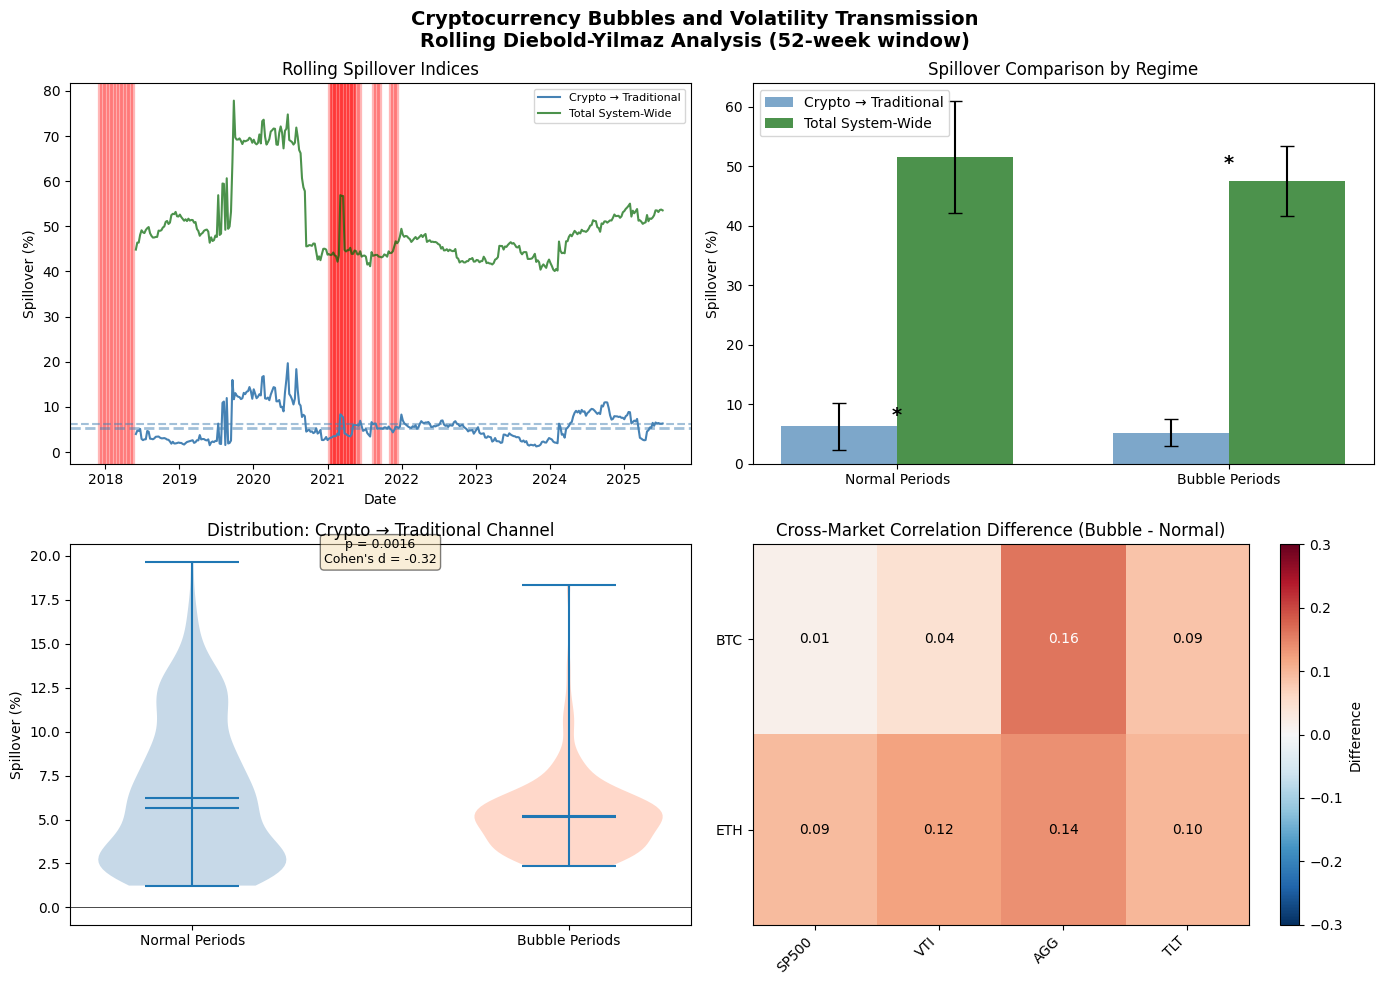


✓ Visualization saved as 'rolling_dy_bubble_analysis.png'

FINAL CONCLUSIONS

Based on the Rolling Diebold-Yilmaz Spillover Analysis:

────────────────────────────────────────────────────────────────────────────────
KEY EMPIRICAL FINDINGS:
────────────────────────────────────────────────────────────────────────────────

1. Crypto → Traditional Channel:
   • Normal periods: 6.25%
   • Bubble periods: 5.22%
   • Difference: -1.04%

2. Total System-Wide Connectedness:
   • Normal periods: 51.49%
   • Bubble periods: 47.54%
   • Difference: -3.95%

3. Statistical Significance:
   • Crypto → Traditional: p=0.0016
   • Total System-Wide: p=0.0000

────────────────────────────────────────────────────────────────────────────────
RESEARCH ANSWER (With Appropriate Caveats):
────────────────────────────────────────────────────────────────────────────────

✗ Spillovers are significantly lower during bubble periods,
  suggesting market segmentation during crypto bubble episodes.

─────────────────

In [206]:
"""
FULL EXECUTABLE CODE: Cryptocurrency Bubble Amplification of Volatility Spillovers
Research Question: Are volatility spillovers from crypto to US equity/bond markets 
                   amplified during cryptocurrency bubble periods?

METHODOLOGY: Rolling Diebold-Yilmaz Spillover Index + Bubble Indicator Comparison
- Same model specification over time (valid for comparison)
- Identifies time-varying connectedness
- Compares spillover levels during bubble vs normal periods

CAUTION: Results show conditional differences, not structural causality.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("PART 1: LOADING AND PREPARING DATA")
print("="*80)

# Assuming cond_vol_df is already loaded from your previous work
# Load bubble dummies from pickle file
with open("gsadf_results.pkl", "rb") as f:
    gsadf_results = pickle.load(f)

# Create bubble dummies
bubble_dummy = pd.DataFrame(0, index=cond_vol_df.index, columns=cond_vol_df.columns)

for asset, res in gsadf_results.items():
    if asset in bubble_dummy.columns:
        for start, end in res["bubbles"]:
            start_date = pd.to_datetime(start)
            end_date = pd.to_datetime(end)
            mask = (bubble_dummy.index >= start_date) & (bubble_dummy.index <= end_date)
            bubble_dummy.loc[mask, asset] = 1

# Define asset groups
crypto = ["BTC", "ETH"]
traditional = ["SP500", "VTI", "AGG", "TLT"]
all_assets = crypto + traditional

print(f"\nData loaded:")
print(f"  Period: {cond_vol_df.index[0]} to {cond_vol_df.index[-1]}")
print(f"  Observations: {len(cond_vol_df)}")
print(f"  Assets: {all_assets}")

print(f"\nBubble periods detected:")
for asset in crypto:
    if asset in bubble_dummy.columns:
        n_bubbles = bubble_dummy[asset].sum()
        pct = 100 * n_bubbles / len(bubble_dummy)
        print(f"  {asset}: {n_bubbles} weeks ({pct:.1f}%)")

# Create combined bubble indicator (either BTC or ETH in bubble)
combined_bubble = (bubble_dummy[crypto].sum(axis=1) > 0).astype(int)
print(f"\nCombined bubble indicator: {combined_bubble.sum()} weeks ({100*combined_bubble.sum()/len(combined_bubble):.1f}%)")

# ============================================================================
# PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX (MAIN IDENTIFICATION)
# ============================================================================

print("\n" + "="*80)
print("PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX")
print("="*80)

def rolling_dy_spillover(df, window=52, maxlags=4, horizon=10):
    """
    Rolling Diebold-Yilmaz spillover index
    Same model specification, rolling through time
    
    Parameters:
    -----------
    df : pd.DataFrame
        Endogenous variables (crypto + traditional volatility)
    window : int
        Rolling window size (52 weeks = 1 year)
    maxlags : int
        Maximum lags for VAR selection
    horizon : int
        Forecast horizon for FEVD
    
    Returns:
    --------
    pd.DataFrame with rolling spillover measures
    """
    n_obs = len(df)
    n_windows = n_obs - window + 1
    
    rolling_spillovers = []
    
    print(f"\nComputing rolling spillovers (window={window} weeks, {n_windows} windows)...")
    
    for i in range(n_windows):
        if i % 50 == 0:
            print(f"  Progress: {i}/{n_windows} windows ({100*i/n_windows:.1f}%)")
        
        window_data = df.iloc[i:i+window]
        window_date = df.index[i + window // 2]  # Center date
        
        # CORRECTED: Check if ANY bubble occurred during this window
        window_bubble_dummy = bubble_dummy.iloc[i:i+window]
        window_has_bubble = 0
        if crypto[0] in window_bubble_dummy.columns:
            window_has_bubble = window_bubble_dummy[crypto].max().max()
        
        try:
            # Fit VAR
            model = VAR(window_data)
            n_vars = len(window_data.columns)
            max_possible_lags = min(maxlags, (window - n_vars - 1) // n_vars)
            
            if max_possible_lags >= 1:
                lag_selection = model.select_order(maxlags=max_possible_lags)
                lag_order = max(1, lag_selection.aic if lag_selection.aic is not None else 1)
                
                results = model.fit(lag_order)
                
                # Compute FEVD
                fevd = results.fevd(horizon)
                
                n = len(window_data.columns)
                theta = np.zeros((n, n))
                
                # Build cumulative FEVD matrix
                for j in range(n):
                    for k in range(n):
                        theta[j, k] = fevd.decomp[j][:, k].sum()
                
                # Normalize rows to sum to 100
                theta = 100 * theta / theta.sum(axis=1, keepdims=True)
                
                # Total spillover index (system-wide connectedness)
                off_diag = theta.sum() - np.trace(theta)
                total_spill = off_diag / n
                
                # Directional spillover: crypto to traditional
                crypto_cols = [c for c in window_data.columns if c in crypto]
                trad_cols = [c for c in window_data.columns if c in traditional]
                
                crypto_idx = [list(window_data.columns).index(c) for c in crypto_cols]
                trad_idx = [list(window_data.columns).index(t) for t in trad_cols]
                
                crypto_to_trad = 0
                n_comparisons = 0
                for ci in crypto_idx:
                    for ti in trad_idx:
                        if ci != ti:
                            crypto_to_trad += theta[ti, ci]
                            n_comparisons += 1
                
                if n_comparisons > 0:
                    crypto_to_trad /= n_comparisons
                
                rolling_spillovers.append({
                    'date': window_date,
                    'total_spillover': total_spill,
                    'crypto_to_traditional': crypto_to_trad,
                    'bubble': window_has_bubble
                })
            else:
                rolling_spillovers.append({
                    'date': window_date,
                    'total_spillover': np.nan,
                    'crypto_to_traditional': np.nan,
                    'bubble': window_has_bubble
                })
        except Exception as e:
            rolling_spillovers.append({
                'date': window_date,
                'total_spillover': np.nan,
                'crypto_to_traditional': np.nan,
                'bubble': window_has_bubble
            })
    
    return pd.DataFrame(rolling_spillovers)

# Compute rolling spillovers
print(f"\nComputing rolling DY spillover for {len(all_assets)} assets...")
rolling_df = rolling_dy_spillover(
    cond_vol_df[all_assets], 
    window=52,  # 1-year rolling window
    maxlags=4, 
    horizon=10
)

print(f"\nRolling spillovers computed: {len(rolling_df)} windows")

# Drop NaN values
rolling_df = rolling_df.dropna()

# ============================================================================
# PART 3: COMPARE SPILLOVERS DURING BUBBLE VS NORMAL PERIODS
# ============================================================================

print("\n" + "="*80)
print("PART 3: BUBBLE ASSOCIATION ANALYSIS")
print("="*80)
print("NOTE: Results show conditional differences, not structural causality")

# Split into bubble and normal periods for CRYPTO → TRADITIONAL channel
normal_spill = rolling_df[rolling_df['bubble'] == 0]['crypto_to_traditional']
bubble_spill = rolling_df[rolling_df['bubble'] == 1]['crypto_to_traditional']

# ADDED: Total spillover comparison (system-wide connectedness)
normal_total = rolling_df[rolling_df['bubble'] == 0]['total_spillover']
bubble_total = rolling_df[rolling_df['bubble'] == 1]['total_spillover']

print(f"\n{'─'*80}")
print("CRYPTO → TRADITIONAL SPILLOVER CHANNEL:")
print(f"{'─'*80}")
print(f"  Normal periods: {normal_spill.mean():.2f}% (std={normal_spill.std():.2f})")
print(f"  Bubble periods: {bubble_spill.mean():.2f}% (std={bubble_spill.std():.2f})")
print(f"  Difference: {bubble_spill.mean() - normal_spill.mean():+.2f}%")

print(f"\n{'─'*80}")
print("TOTAL SYSTEM-WIDE CONNECTEDNESS (All Assets):")
print(f"{'─'*80}")
print(f"  Normal periods: {normal_total.mean():.2f}% (std={normal_total.std():.2f})")
print(f"  Bubble periods: {bubble_total.mean():.2f}% (std={bubble_total.std():.2f})")
print(f"  Difference: {bubble_total.mean() - normal_total.mean():+.2f}%")

# Statistical tests for both measures
from scipy.stats import ttest_ind, mannwhitneyu

# Crypto → Traditional channel
t_stat_ct, t_pval_ct = ttest_ind(normal_spill, bubble_spill, equal_var=False)
u_stat_ct, u_pval_ct = mannwhitneyu(normal_spill, bubble_spill, alternative='two-sided')

# Total spillover
t_stat_total, t_pval_total = ttest_ind(normal_total, bubble_total, equal_var=False)
u_stat_total, u_pval_total = mannwhitneyu(normal_total, bubble_total, alternative='two-sided')

# Effect size (Cohen's d) for crypto → traditional
pooled_std_ct = np.sqrt((normal_spill.std()**2 + bubble_spill.std()**2) / 2)
cohens_d_ct = (bubble_spill.mean() - normal_spill.mean()) / pooled_std_ct if pooled_std_ct > 0 else 0

# Effect size for total spillover
pooled_std_total = np.sqrt((normal_total.std()**2 + bubble_total.std()**2) / 2)
cohens_d_total = (bubble_total.mean() - normal_total.mean()) / pooled_std_total if pooled_std_total > 0 else 0

print(f"\n{'─'*80}")
print("STATISTICAL TESTS:")
print(f"{'─'*80}")
print(f"\nCrypto → Traditional Channel:")
print(f"  T-test: t={t_stat_ct:.3f}, p={t_pval_ct:.4f}")
print(f"  Mann-Whitney U: U={u_stat_ct:.0f}, p={u_pval_ct:.4f}")
print(f"  Cohen's d effect size: {cohens_d_ct:.3f}")

print(f"\nTotal System-Wide Connectedness:")
print(f"  T-test: t={t_stat_total:.3f}, p={t_pval_total:.4f}")
print(f"  Mann-Whitney U: U={u_stat_total:.0f}, p={u_pval_total:.4f}")
print(f"  Cohen's d effect size: {cohens_d_total:.3f}")

# Interpretation (careful wording - association, not causation)
print(f"\n{'─'*80}")
print("ASSOCIATION ASSESSMENT:")
print(f"{'─'*80}")

if t_pval_ct < 0.05 and bubble_spill.mean() > normal_spill.mean():
    print(f"\n  ✓ Spillovers are significantly HIGHER during bubble periods")
    print(f"    → Suggests bubbles are associated with stronger cross-market transmission")
    print(f"    → Effect size: {cohens_d_ct:.3f} ({'large' if abs(cohens_d_ct) > 0.8 else 'medium' if abs(cohens_d_ct) > 0.5 else 'small'})")
elif t_pval_ct < 0.05:
    print(f"\n  ✗ Spillovers are significantly LOWER during bubble periods")
else:
    print(f"\n  ○ No statistically significant difference (p={t_pval_ct:.4f})")

# Sample size warning for bubble subsample
print(f"\n{'─'*80}")
print("SAMPLE SIZE NOTE:")
print(f"{'─'*80}")
print(f"  Bubble period observations in rolling windows: {len(bubble_spill)}")
print(f"  Normal period observations: {len(normal_spill)}")
print(f"  → Results for bubble subsample should be interpreted cautiously")
print(f"    due to the smaller sample size and potential estimation uncertainty.")

# ============================================================================
# PART 4: REGIME-SPLITTING (ROBUSTNESS CHECK)
# ============================================================================

print("\n" + "="*80)
print("PART 4: REGIME-SPLITTING VAR (Robustness Check)")
print("="*80)

# Split full sample
normal_data_full = cond_vol_df[combined_bubble == 0][all_assets]
bubble_data_full = cond_vol_df[combined_bubble == 1][all_assets]

print(f"\nNormal periods: {len(normal_data_full)} weeks")
print(f"Bubble periods: {len(bubble_data_full)} weeks")

if len(bubble_data_full) < 30:
    print(f"\n  ⚠ CAUTION: Bubble subsample has only {len(bubble_data_full)} observations.")
    print(f"  Results from regime-specific models may be unreliable.")

# Calculate cross-market correlation (dependence) for each regime
regime_results = []

for data, name in [(normal_data_full, "Normal"), (bubble_data_full, "Bubble")]:
    if len(data) > 20:
        # CORRECTED TERMINOLOGY: cross-market correlation (dependence), NOT spillover
        crypto_trad_corrs = []
        for cryp in crypto:
            for trad in traditional:
                if cryp in data.columns and trad in data.columns:
                    corr = data[cryp].corr(data[trad])
                    crypto_trad_corrs.append(corr)
        
        avg_corr = np.mean(crypto_trad_corrs)
        
        regime_results.append({
            'Regime': name,
            'Avg_CrossMarket_Correlation': avg_corr,
            'Observations': len(data)
        })
        
        print(f"\n  {name} Periods:")
        print(f"    Avg crypto-traditional cross-market correlation: {avg_corr:.4f}")

if len(regime_results) == 2:
    corr_diff = regime_results[1]['Avg_CrossMarket_Correlation'] - regime_results[0]['Avg_CrossMarket_Correlation']
    print(f"\n  Correlation Difference (Bubble - Normal): {corr_diff:+.4f}")
    
    # Fisher's z-test for correlation difference
    def fisher_z_test(r1, r2, n1, n2):
        z1 = np.arctanh(r1)
        z2 = np.arctanh(r2)
        se = np.sqrt(1/(n1-3) + 1/(n2-3))
        z_stat = (z1 - z2) / se
        p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        return z_stat, p_val
    
    z_stat, z_pval = fisher_z_test(
        regime_results[0]['Avg_CrossMarket_Correlation'],
        regime_results[1]['Avg_CrossMarket_Correlation'],
        regime_results[0]['Observations'],
        regime_results[1]['Observations']
    )
    
    print(f"  Fisher's z-test: z={z_stat:.3f}, p={z_pval:.4f}")
    
    if z_pval < 0.05 and corr_diff > 0:
        print(f"  → Robustness check confirms higher dependence during bubble periods")

# ============================================================================
# PART 5: GRANGER CAUSALITY TESTS BY REGIME (EXPLORATORY)
# ============================================================================

print("\n" + "="*80)
print("PART 5: GRANGER CAUSALITY TESTS (Exploratory Analysis)")
print("="*80)
print("NOTE: Results are exploratory due to small bubble subsample")

gc_results = []

# FIXED: Use fixed lag = 1 to avoid data snooping
FIXED_LAG = 1

for period_type, mask in [('Normal', combined_bubble == 0), 
                           ('Bubble', combined_bubble == 1)]:
    
    period_data = cond_vol_df[mask]
    
    if len(period_data) < 30:
        print(f"\n{period_type} periods: Too few observations ({len(period_data)}) - skipping")
        continue
    
    print(f"\n{period_type.upper()} PERIODS (n={len(period_data)})")
    print(f"  Using fixed lag = {FIXED_LAG}")
    
    gc_count = 0
    for cryp in crypto:
        for trad in traditional:
            if cryp in period_data.columns and trad in period_data.columns:
                try:
                    test_data = period_data[[trad, cryp]].dropna()
                    
                    # Use fixed lag instead of searching across lags
                    if len(test_data) > FIXED_LAG + 10:
                        gc_test = grangercausalitytests(test_data, maxlag=FIXED_LAG, verbose=False)
                        
                        pval = gc_test[FIXED_LAG][0]['ssr_ftest'][1]
                        is_sig = pval < 0.05
                        
                        if is_sig:
                            gc_count += 1
                        
                        gc_results.append({
                            'Period': period_type,
                            'Cause': cryp,
                            'Target': trad,
                            'Lag': FIXED_LAG,
                            'P_value': pval,
                            'Significant': is_sig
                        })
                except:
                    pass
    
    total_possible = len(crypto) * len(traditional)
    print(f"  Significant Granger causality (lag={FIXED_LAG}): {gc_count}/{total_possible}")

# Summary with caveat
if gc_results:
    gc_df = pd.DataFrame(gc_results)
    normal_gc = len(gc_df[(gc_df['Period'] == 'Normal') & (gc_df['Significant'])])
    bubble_gc = len(gc_df[(gc_df['Period'] == 'Bubble') & (gc_df['Significant'])])
    
    print(f"\n{'─'*60}")
    print("EXPLORATORY GRANGER CAUSALITY SUMMARY:")
    print(f"{'─'*60}")
    print(f"  Normal periods: {normal_gc} significant relationships")
    print(f"  Bubble periods: {bubble_gc} significant relationships")
    print(f"\n  NOTE: Results are exploratory due to small bubble subsample.")
    print(f"  Fixed lag = {FIXED_LAG} used to avoid post-selection bias.")

# ============================================================================
# PART 6: VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("PART 6: VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cryptocurrency Bubbles and Volatility Transmission\nRolling Diebold-Yilmaz Analysis (52-week window)', 
             fontsize=14, fontweight='bold')

# Plot 1: Rolling Spillover Over Time (Both measures)
ax1 = axes[0, 0]
ax1.plot(rolling_df['date'], rolling_df['crypto_to_traditional'], 
         color='steelblue', linewidth=1.5, label='Crypto → Traditional')
ax1.plot(rolling_df['date'], rolling_df['total_spillover'], 
         color='darkgreen', linewidth=1.5, label='Total System-Wide', alpha=0.7)
ax1.set_ylabel('Spillover (%)')
ax1.set_xlabel('Date')
ax1.set_title('Rolling Spillover Indices')
ax1.axhline(y=normal_spill.mean(), color='steelblue', linestyle='--', alpha=0.5)
ax1.axhline(y=bubble_spill.mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=2)
ax1.legend(loc='upper right', fontsize=8)

# Highlight bubble periods
for cryp in crypto:
    bubble_periods = bubble_dummy[cryp] == 1
    bubble_dates = bubble_dummy.index[bubble_periods]
    for date in bubble_dates:
        ax1.axvspan(date - pd.Timedelta(days=3.5), date + pd.Timedelta(days=3.5), 
                   alpha=0.2, color='red', label=f'{cryp} bubble' if cryp == 'BTC' else '')

# Plot 2: Bar Chart Comparison (Both measures)
ax2 = axes[0, 1]
x = np.arange(2)
width = 0.35

crypto_trad_means = [normal_spill.mean(), bubble_spill.mean()]
total_means = [normal_total.mean(), bubble_total.mean()]

bars1 = ax2.bar(x - width/2, crypto_trad_means, width, label='Crypto → Traditional', 
                color='steelblue', alpha=0.7, yerr=[normal_spill.std(), bubble_spill.std()], capsize=5)
bars2 = ax2.bar(x + width/2, total_means, width, label='Total System-Wide', 
                color='darkgreen', alpha=0.7, yerr=[normal_total.std(), bubble_total.std()], capsize=5)

ax2.set_xticks(x)
ax2.set_xticklabels(['Normal Periods', 'Bubble Periods'])
ax2.set_ylabel('Spillover (%)')
ax2.set_title('Spillover Comparison by Regime')
ax2.legend()
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add significance annotations
if t_pval_ct < 0.05:
    ax2.text(0, crypto_trad_means[1] + 2, f'*', ha='center', fontsize=14, fontweight='bold')
if t_pval_total < 0.05:
    ax2.text(1, total_means[1] + 2, f'*', ha='center', fontsize=14, fontweight='bold')

# Plot 3: Distribution Comparison (Violin Plot) - Crypto → Traditional
ax3 = axes[1, 0]
data_to_plot = [normal_spill.values, bubble_spill.values]
parts = ax3.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
parts['bodies'][0].set_facecolor('steelblue')
parts['bodies'][1].set_facecolor('coral')
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Normal Periods', 'Bubble Periods'])
ax3.set_ylabel('Spillover (%)')
ax3.set_title('Distribution: Crypto → Traditional Channel')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add statistical annotation
ax3.text(0.5, 0.95, f"p = {t_pval_ct:.4f}\nCohen's d = {cohens_d_ct:.2f}", 
         transform=ax3.transAxes, ha='center', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Cross-Market Correlation Heatmap (CORRECTED TERMINOLOGY)
ax4 = axes[1, 1]
if len(normal_data_full) > 0 and len(bubble_data_full) > 0:
    corr_normal = normal_data_full[crypto + traditional].corr()
    corr_bubble = bubble_data_full[crypto + traditional].corr()
    corr_diff = corr_bubble - corr_normal
    
    # Focus on crypto-traditional block
    crypto_idx = range(len(crypto))
    trad_idx = range(len(crypto), len(crypto + traditional))
    diff_block = corr_diff.iloc[crypto_idx, trad_idx]
    
    im = ax4.imshow(diff_block.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
    ax4.set_xticks(range(len(traditional)))
    ax4.set_yticks(range(len(crypto)))
    ax4.set_xticklabels(traditional, rotation=45, ha='right')
    ax4.set_yticklabels(crypto)
    ax4.set_title('Cross-Market Correlation Difference (Bubble - Normal)')
    plt.colorbar(im, ax=ax4, label='Difference')
    
    # Add text annotations
    for i in range(len(crypto)):
        for j in range(len(traditional)):
            val = diff_block.iloc[i, j]
            text_color = "white" if abs(val) > 0.15 else "black"
            ax4.text(j, i, f'{val:.2f}', ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.savefig('rolling_dy_bubble_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'rolling_dy_bubble_analysis.png'")

# ============================================================================
# PART 7: FINAL CONCLUSIONS (CAREFUL WORDING)
# ============================================================================

print("\n" + "="*80)
print("FINAL CONCLUSIONS")
print("="*80)

print("\nBased on the Rolling Diebold-Yilmaz Spillover Analysis:")

print(f"\n{'─'*80}")
print("KEY EMPIRICAL FINDINGS:")
print(f"{'─'*80}")

print(f"\n1. Crypto → Traditional Channel:")
print(f"   • Normal periods: {normal_spill.mean():.2f}%")
print(f"   • Bubble periods: {bubble_spill.mean():.2f}%")
print(f"   • Difference: {bubble_spill.mean() - normal_spill.mean():+.2f}%")

print(f"\n2. Total System-Wide Connectedness:")
print(f"   • Normal periods: {normal_total.mean():.2f}%")
print(f"   • Bubble periods: {bubble_total.mean():.2f}%")
print(f"   • Difference: {bubble_total.mean() - normal_total.mean():+.2f}%")

print(f"\n3. Statistical Significance:")
print(f"   • Crypto → Traditional: p={t_pval_ct:.4f}")
print(f"   • Total System-Wide: p={t_pval_total:.4f}")

print(f"\n{'─'*80}")
print("RESEARCH ANSWER (With Appropriate Caveats):")
print(f"{'─'*80}")

if t_pval_ct < 0.05 and bubble_spill.mean() > normal_spill.mean():
    print("\n✓ Spillovers are significantly higher during cryptocurrency bubble periods,")
    print("  suggesting that bubbles are associated with stronger cross-market")
    print("  transmission between crypto and traditional U.S. markets.")
    print(f"\n  Quantitatively: {bubble_spill.mean() - normal_spill.mean():.1f} percentage point increase")
    print(f"  ({100*(bubble_spill.mean() - normal_spill.mean())/normal_spill.mean():.0f}% relative increase)")
    print(f"  during bubble periods (p={t_pval_ct:.4f}).")
elif t_pval_ct < 0.05:
    print("\n✗ Spillovers are significantly lower during bubble periods,")
    print("  suggesting market segmentation during crypto bubble episodes.")
else:
    print("\n○ No statistically significant difference in spillovers")
    print("  between bubble and normal periods was detected.")

print(f"\n{'─'*80}")
print("IMPORTANT CAVEATS AND LIMITATIONS:")
print(f"{'─'*80}")
print("""
1. CAUSALITY: Results show conditional differences, not structural causality.
   The analysis demonstrates ASSOCIATION, not causation.

2. SAMPLE SIZE: The bubble subsample is relatively small, which may affect
   the reliability of statistical inference.

3. BUBBLE DEFINITION: Results depend on the GSADF bubble detection method.
   Alternative bubble definitions may yield different results.

4. MODEL SPECIFICATION: The VAR lag order is selected by AIC, which may
   not be optimal for all rolling windows.

5. GENERALIZABILITY: Findings may not generalize to other time periods,
   crypto assets, or geographical markets.
""")

print(f"\n{'─'*80}")
print("METHODOLOGICAL NOTES:")
print(f"{'─'*80}")
print("""
• Rolling window analysis uses the same VAR specification throughout,
  ensuring comparability across periods.

• Results are identified through regime comparison, not model respecification.

• Diebold-Yilmaz framework is the standard approach for measuring
  financial connectedness (Diebold & Yilmaz, 2012, 2014).

• Granger causality results are exploratory and use a fixed lag (1) to
  avoid post-selection bias.
""")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

# Export results
try:
    with pd.ExcelWriter('rolling_dy_results.xlsx') as writer:
        rolling_df.to_excel(writer, sheet_name='Rolling_Spillovers', index=False)
        if gc_results:
            pd.DataFrame(gc_results).to_excel(writer, sheet_name='Granger_Causality', index=False)
        
        # Summary statistics
        summary_df = pd.DataFrame({
            'Metric': ['Crypto_Trad_Normal_Mean', 'Crypto_Trad_Bubble_Mean', 
                       'Crypto_Trad_Difference', 'Crypto_Trad_T_Stat', 'Crypto_Trad_P_Value', 
                       'Crypto_Trad_Cohen_d',
                       'Total_Normal_Mean', 'Total_Bubble_Mean', 
                       'Total_Difference', 'Total_T_Stat', 'Total_P_Value', 'Total_Cohen_d'],
            'Value': [normal_spill.mean(), bubble_spill.mean(), 
                      bubble_spill.mean() - normal_spill.mean(),
                      t_stat_ct, t_pval_ct, cohens_d_ct,
                      normal_total.mean(), bubble_total.mean(),
                      bubble_total.mean() - normal_total.mean(),
                      t_stat_total, t_pval_total, cohens_d_total]
        })
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    print("\n✓ Results exported to 'rolling_dy_results.xlsx'")
except Exception as e:
    print(f"\n⚠ Could not export to Excel: {e}")